/home/hail/anaconda3/envs/tagnet/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


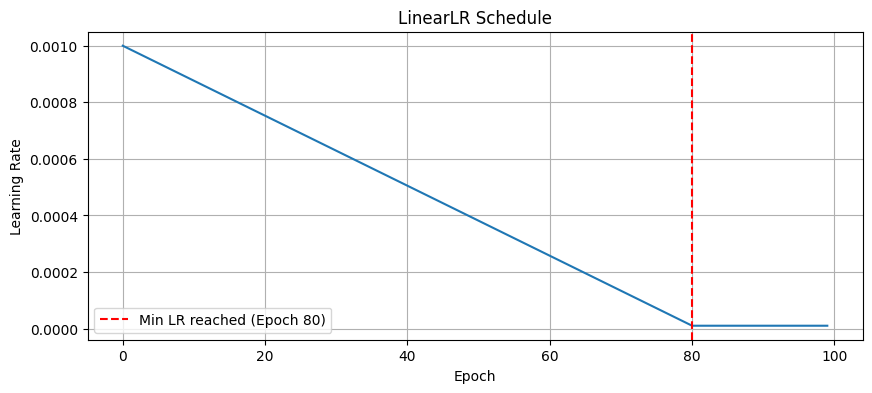

In [2]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR
import matplotlib.pyplot as plt

# --- 하이퍼파라미터 설정 ---
START_LR = 1e-3
MIN_LR = 1e-5
TOTAL_EPOCHS = 100
DECAY_PROPORTION = 0.8  # 전체 epoch의 80% 시점에 최소값 도달

# 모델과 옵티마이저 (예시)
model = torch.nn.Linear(10, 2)
optimizer = optim.Adam(model.parameters(), lr=START_LR)

# --- 스케줄러 계산 ---
# 1. 최소값에 도달할 epoch 수 계산
decay_epochs = int(TOTAL_EPOCHS * DECAY_PROPORTION)

# 2. 최소 LR은 시작 LR의 몇 배인지 계산 (end_factor)
min_lr_factor = MIN_LR / START_LR

# 3. LinearLR 스케줄러 생성
scheduler = LinearLR(
    optimizer,
    start_factor=1.0,      # 1.0 * START_LR 에서 시작
    end_factor=min_lr_factor,  # min_lr_factor * START_LR 에서 종료
    total_iters=decay_epochs # decay_epochs 만큼 걸려서 도달
)

# --- 학습 루프 (시뮬레이션) ---
lrs = []
for epoch in range(TOTAL_EPOCHS):
    # train() ...
    # valid() ...
    
    # 현재 LR 기록
    lrs.append(optimizer.param_groups[0]['lr'])
    
    # 옵티마이저 업데이트 후 스케줄러 스텝
    # optimizer.step() 
    scheduler.step()

# --- 결과 시각화 ---
plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.title("LinearLR Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.axvline(x=decay_epochs, color='r', linestyle='--', label=f'Min LR reached (Epoch {decay_epochs})')
plt.legend()
plt.grid(True)
plt.show()

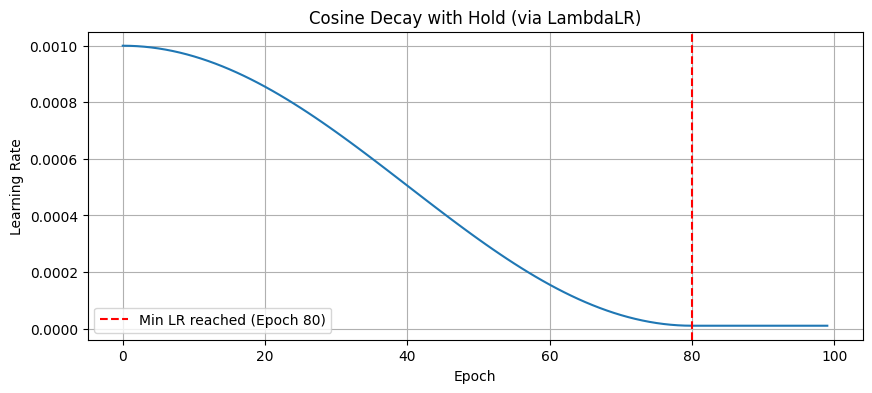

In [3]:
import math
from torch.optim.lr_scheduler import LambdaLR

# --- 하이퍼파라미터 (동일) ---
START_LR = 1e-3
MIN_LR = 1e-5
TOTAL_EPOCHS = 100
DECAY_PROPORTION = 0.8

model = torch.nn.Linear(10, 2)
optimizer = optim.Adam(model.parameters(), lr=START_LR)

# --- 스케줄러 계산 ---
decay_epochs = int(TOTAL_EPOCHS * DECAY_PROPORTION)
min_lr_ratio = MIN_LR / START_LR

# 'LambdaLR'에 전달할 함수 정의
def get_cosine_decay_with_hold(current_epoch):
    if current_epoch < decay_epochs:
        # 1.0 (시작) 에서 min_lr_ratio (끝) 까지 코사인 곡선으로 감소
        progress = float(current_epoch) / float(decay_epochs)
        cosine_factor = 0.5 * (1.0 + math.cos(math.pi * progress))
        
        # 1.0 과 min_lr_ratio 사이를 cosine_factor로 보간
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine_factor
    else:
        # decay_epochs 이후에는 최소 배율 유지
        return min_lr_ratio

# LambdaLR 스케줄러 생성
scheduler_cosine = LambdaLR(optimizer, lr_lambda=get_cosine_decay_with_hold)

# --- 학습 루프 (시뮬레이션) ---
lrs_cosine = []
for epoch in range(TOTAL_EPOCHS):
    lrs_cosine.append(optimizer.param_groups[0]['lr'])
    # optimizer.step()
    scheduler_cosine.step()

# --- 결과 시각화 ---
plt.figure(figsize=(10, 4))
plt.plot(lrs_cosine)
plt.title("Cosine Decay with Hold (via LambdaLR)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.axvline(x=decay_epochs, color='r', linestyle='--', label=f'Min LR reached (Epoch {decay_epochs})')
plt.legend()
plt.grid(True)
plt.show()
